In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
import matplotlib.pyplot as plt

LOADING AND PREPROCESSING

In [ ]:
print("BREAST CANCER WISCONSIN DATASET - MACHINE LEARNING ANALYSIS")

BREAST CANCER WISCONSIN DATASET - MACHINE LEARNING ANALYSIS


In [ ]:
# Load data (no header, comma-separated)
# Column 0: ID, Column 1: Diagnosis (M/B), Columns 2-31: 30 features
data = pd.read_csv('/content/drive/MyDrive/AK-CG ML PROJECT/breast cancer/wdbc.data', header=None)

In [ ]:
# Column names (features) based on wdbc.names
feature_names = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness',
                 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

In [ ]:
# Create column names: ID, diagnosis, then mean/se/worst for each feature
columns = ['id', 'diagnosis']
for prefix in ['mean_', 'se_', 'worst_']:
    for feature in feature_names:
        columns.append(prefix + feature)

In [ ]:
data.columns = columns

In [ ]:
print(data.describe().T[["min", "max", "mean", "std"]])
# data.hist(bins=25, figsize=(15,10))
# plt.show()

                                 min           max          mean           std
id                       8670.000000  9.113205e+08  3.037183e+07  1.250206e+08
mean_radius                 6.981000  2.811000e+01  1.412729e+01  3.524049e+00
mean_texture                9.710000  3.928000e+01  1.928965e+01  4.301036e+00
mean_perimeter             43.790000  1.885000e+02  9.196903e+01  2.429898e+01
mean_area                 143.500000  2.501000e+03  6.548891e+02  3.519141e+02
mean_smoothness             0.052630  1.634000e-01  9.636028e-02  1.406413e-02
mean_compactness            0.019380  3.454000e-01  1.043410e-01  5.281276e-02
mean_concavity              0.000000  4.268000e-01  8.879932e-02  7.971981e-02
mean_concave_points         0.000000  2.012000e-01  4.891915e-02  3.880284e-02
mean_symmetry               0.106000  3.040000e-01  1.811619e-01  2.741428e-02
mean_fractal_dimension      0.049960  9.744000e-02  6.279761e-02  7.060363e-03
se_radius                   0.111500  2.873000e+00  

In [ ]:
# Verify column creation
print(f"\nTotal columns created: {len(columns)}")
print(f"Expected: 2 (id, diagnosis) + 30 features = 32 columns")
print(f"Actual feature columns: {len(columns) - 2}")


Total columns created: 32
Expected: 2 (id, diagnosis) + 30 features = 32 columns
Actual feature columns: 30


In [ ]:
# Separate features and target
X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis']

In [ ]:
# Verify we have all 30 features
if X.shape[1] != 30:
    print(f"\nWARNING: Expected 30 features, but got {X.shape[1]} features!")
    print(f"Feature columns: {list(X.columns)}")
else:
    print(f"\n✓ Successfully loaded all 30 features")


✓ Successfully loaded all 30 features


In [ ]:
# Encode target variable (M=1, B=0)
le_target = LabelEncoder()
y = le_target.fit_transform(y)  # M=1, B=0

In [ ]:
# # Split into train and test
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

In [ ]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = scaler.transform(X)

In [ ]:
print(f"\nDataset Shape: {data.shape}")
# print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
# print(f"Features: {X_train.shape[1]} (should be 30)")
print(f"Target distribution: {np.bincount(y)}")



Dataset Shape: (569, 32)
Target distribution: [357 212]


In [ ]:
def evaluate_model(model, X, y, cv):
    """
    Evaluates a model using cross-validation and returns mean and variance of specified metrics.

    Args:
        model: The scikit-learn model to evaluate.
        X (pd.DataFrame or np.array): Features.
        y (pd.Series or np.array): Target variable.
        cv (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing mean and variance for accuracy, F1-score, and ROC AUC.
    """
    cv_results = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])

    mean_accuracy = cv_results['test_accuracy'].mean()
    mean_f1 = cv_results['test_f1'].mean()
    mean_auc = cv_results['test_roc_auc'].mean()

    return {
        'Mean Accuracy': mean_accuracy,
        'Mean F1 Score': mean_f1,
        'Mean AUC': mean_auc,
    }

In [ ]:
# function to plot metrics vs changing hyperparameters

def plot_metrics(df, x, title, log_scale=False):
    plt.figure(figsize=(8,5))

    # Always convert x column to string to handle mixed types (e.g., gamma)
    x_vals = df[x].astype(str)

    plt.plot(x_vals, df["Mean Accuracy"], marker='o', label="Accuracy")
    plt.plot(x_vals, df["Mean F1"], marker='o', label="F1 Score")
    plt.plot(x_vals, df["Mean AUC"], marker='o', label="AUC RUC")

    # Log scale only applies to true numeric x values
    if log_scale:
        # Only apply log scale if values are numeric
        try:
            numeric_vals = pd.to_numeric(df[x], errors='raise')
            plt.xscale("log")
        except:
            print("⚠ Log scale ignored: X axis contains non-numeric values.")

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid(True)
    plt.show()


# LOGISTIC REGRESSION


In [ ]:
print("1. LOGISTIC REGRESSION")

# Hyperparameter values
penalties = [None, 'l2', 'l1', 'elasticnet']
solvers = ['liblinear', 'lbfgs', 'saga']
reg_strengths = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

print("\nPerforming Hyperparameter Evaluation...")

###############################################################
# 1 — Across SOLVERS
###############################################################
results1 = []
for solver in solvers:

    if solver == 'liblinear':
        current_penalty = 'l1'
    else:
        current_penalty = 'l2'

    model = LogisticRegression(
        solver=solver,
        penalty=current_penalty,
        C=1,
        max_iter=1000,
        n_jobs=-1
    )
    cv_results = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results1.append({
        'Penalty': model.penalty,
        'Solver': solver,
        'Regularisation Strength': 1.0,
        'L1 Ratio': None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })

###############################################################
# 2 — Across PENALTIES
###############################################################
results2 = []
for penalty in penalties:
    solver_used = '' # To store the actual solver used for printing
    # skip invalid combinations
    if penalty in ['l1', 'elasticnet']:
        solver_used = 'saga'
    else:
        solver_used = 'lbfgs'

    model = LogisticRegression(
        penalty=penalty,
        solver=solver_used,
        C=1,
        l1_ratio=0.5 if penalty == 'elasticnet' else None,
        max_iter=1000,
        n_jobs=-1
    )

    cv_results = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results2.append({
        'Penalty': penalty,
        'Solver': solver_used,
        'Regularisation Strength': 1.0,
        'L1 Ratio': 0.5 if penalty == 'elasticnet' else None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })

###############################################################
# 3 — Across C values
###############################################################
results3 = []
for C in reg_strengths:
    model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=C,
        max_iter=1000,
        n_jobs=-1
    )
    cv_results = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results3.append({
        'Penalty': 'l2',
        'Solver': 'lbfgs',
        'Regularisation Strength': C,
        'L1 Ratio': None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })

###############################################################
# 4 — Across L1 RATIOS
###############################################################
results4 = []
for l1_ratio in L1_ratios:
    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=1,
        l1_ratio=l1_ratio,
        max_iter=1000,
        n_jobs=-1
    )
    cv_results = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results4.append({
        'Penalty': 'elasticnet',
        'Solver': 'saga',
        'Regularisation Strength': 1.0,
        'L1 Ratio': l1_ratio,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })

###############################################################
# Convert to DataFrames
###############################################################
df_results1 = pd.DataFrame(results1)
df_results2 = pd.DataFrame(results2)
df_results3 = pd.DataFrame(results3)
df_results4 = pd.DataFrame(results4)

###############################################################
# Variances
###############################################################
hp_solv_acc = df_results1['Mean Accuracy'].var()
hp_solv_f1 = df_results1['Mean F1'].var()
hp_solv_auc = df_results1['Mean AUC'].var()

hp_pnlt_acc = df_results2['Mean Accuracy'].var()
hp_pnlt_f1 = df_results2['Mean F1'].var()
hp_pnlt_auc = df_results2['Mean AUC'].var()

hp_regs_acc = df_results3['Mean Accuracy'].var()
hp_regs_f1 = df_results3['Mean F1'].var()
hp_regs_auc = df_results3['Mean AUC'].var()

hp_l1ra_acc = df_results4['Mean Accuracy'].var()
hp_l1ra_f1 = df_results4['Mean F1'].var()
hp_l1ra_auc = df_results4['Mean AUC'].var()

print("\nVariance Across Hyperparameters:")
print("Solver Variance (Accuracy):", hp_solv_acc)
print("Solver Variance (F1):", hp_solv_f1)
print("Solver Variance (AUC):", hp_solv_auc)
print("Penalty Variance (Accuracy):", hp_pnlt_acc)
print("Penalty Variance (F1):", hp_pnlt_f1)
print("Penalty Variance (AUC):", hp_pnlt_auc)
print("C Variance (Accuracy):", hp_regs_acc)
print("C Variance (F1):", hp_regs_f1)
print("C Variance (AUC):", hp_regs_auc)
print("L1 Ratio Variance (Accuracy):", hp_l1ra_acc)
print("L1 Ratio Variance (F1):", hp_l1ra_f1)
print("L1 Ratio Variance (AUC):", hp_l1ra_auc)


1. LOGISTIC REGRESSION

Performing Hyperparameter Evaluation...

Variance Across Hyperparameters:
Solver Variance (Accuracy): 0.00010332980529854459
Solver Variance (F1): 0.00016797059560163678
Solver Variance (AUC): 1.1532494740260513e-05
Penalty Variance (Accuracy): 0.00014114363812622822
Penalty Variance (F1): 0.00023129478027504352
Penalty Variance (AUC): 1.3337688146269171e-05
C Variance (Accuracy): 1.4088911187744009e-05
C Variance (F1): 2.644803494806188e-05
C Variance (AUC): 3.663402734719169e-06
L1 Ratio Variance (Accuracy): 0.0
L1 Ratio Variance (F1): 0.0
L1 Ratio Variance (AUC): 0.0


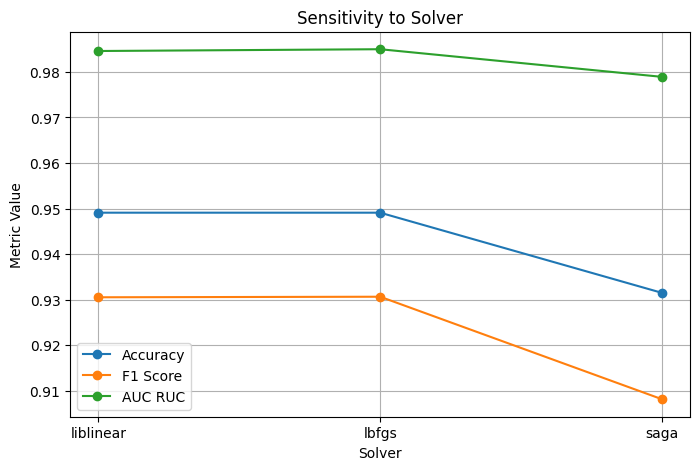

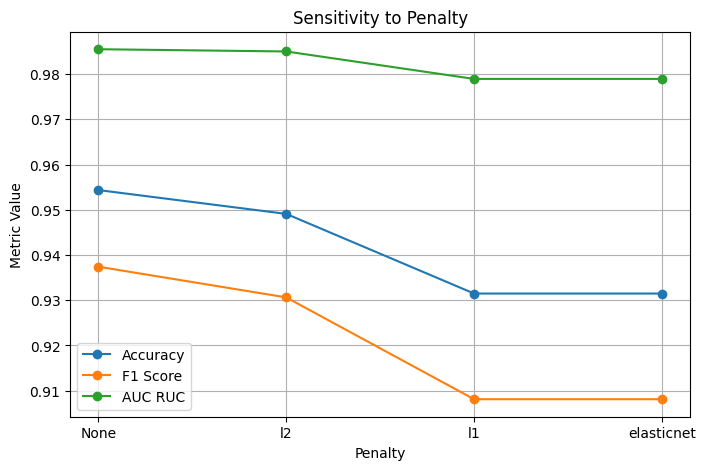

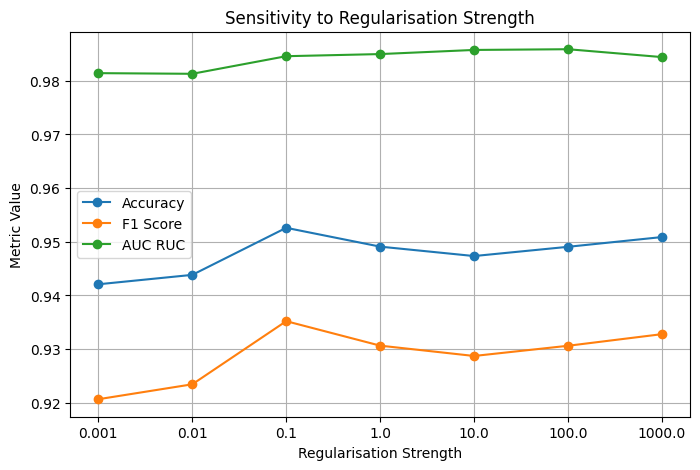

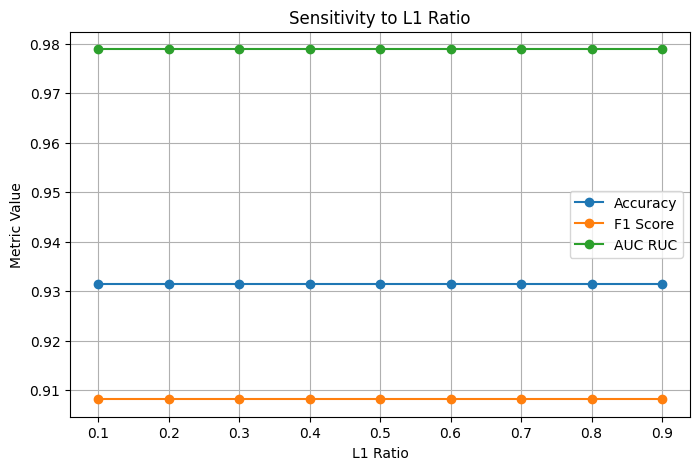

In [ ]:
plot_metrics(df_results1, 'Solver', 'Sensitivity to Solver')
plot_metrics(df_results2, 'Penalty', 'Sensitivity to Penalty')
plot_metrics(df_results3, 'Regularisation Strength', 'Sensitivity to Regularisation Strength')
plot_metrics(df_results4, 'L1 Ratio', 'Sensitivity to L1 Ratio')

# K-NEAREST NEIGHBORS (KNN)

In [ ]:
print("2. K-NEAREST NEIGHBORS (KNN)")
# defining all hyperparameter values
n_neighbors_list = [i for i in range(1,32)]
weights_list = ['uniform','distance']
algorithms_list = ['auto', 'ball_tree', 'kd_tree', 'brute']
metric_list = ['euclidean', 'manhattan', 'minkowski','chebyshev','cosine']

print("\nPerforming Hyperparameter Evaluation for KNN...")

###############################################################
# 1 Across N_Neighbors
###############################################################
knn_n_neighbours_results = []
for k in n_neighbors_list:
    model = KNeighborsClassifier(n_neighbors=k, weights='uniform', algorithm='auto', metric='euclidean')
    metrics = evaluate_model(model, X, y, cv=10)
    knn_n_neighbours_results.append({
        'N Neighbours': k,
        'Weight Metric': 'uniform',
        'Algorithm': 'auto',
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 2 Across Weights
###############################################################
knn_weightmetric_results = []
for w in weights_list:
    model = KNeighborsClassifier(n_neighbors=5, weights=w, algorithm='auto', metric='euclidean')
    metrics = evaluate_model(model, X, y, cv=10)
    knn_weightmetric_results.append({
        'N Neighbours': 5,
        'Weight Metric': w,
        'Algorithm': 'auto',
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 3 Across Algorithms
###############################################################
knn_algorithms_results = []
for a in algorithms_list:
    model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm=a, metric='euclidean')
    metrics = evaluate_model(model, X, y, cv=10)
    knn_algorithms_results.append({
        'N Neighbours': 5,
        'Weight Metric': 'uniform',
        'Algorithm': a,
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 4 Across Distance Metrics
###############################################################
knn_distmetric_results = []
for d in metric_list:
    # cosine metric in KNN does not support p (power parameter for Minkowski metric)
    # and some combinations of algorithm and metric might be incompatible.
    # For simplicity, we'll try to use 'auto' algorithm which handles most cases.
    if d == 'cosine':
        model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='brute', metric=d)
    else:
        model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', metric=d)
    metrics = evaluate_model(model, X, y, cv=10)
    knn_distmetric_results.append({
        'N Neighbours': 5,
        'Weight Metric': 'uniform',
        'Algorithm': 'auto' if d != 'cosine' else 'brute',
        'Distance Metric': d,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# Convert to DataFrames
df_knn_n_neighbours = pd.DataFrame(knn_n_neighbours_results)
df_knn_weightmetric = pd.DataFrame(knn_weightmetric_results)
df_knn_algorithms = pd.DataFrame(knn_algorithms_results)
df_knn_distmetric = pd.DataFrame(knn_distmetric_results)



# Calculate and Print Variances

hp_knn_n_acc = df_knn_n_neighbours['Mean Accuracy'].var()
hp_knn_n_f1 = df_knn_n_neighbours['Mean F1'].var()
hp_knn_n_auc = df_knn_n_neighbours['Mean AUC'].var()

hp_knn_w_acc = df_knn_weightmetric['Mean Accuracy'].var()
hp_knn_w_f1 = df_knn_weightmetric['Mean F1'].var()
hp_knn_w_auc = df_knn_weightmetric['Mean AUC'].var()

hp_knn_a_acc = df_knn_algorithms['Mean Accuracy'].var()
hp_knn_a_f1 = df_knn_algorithms['Mean F1'].var()
hp_knn_a_auc = df_knn_algorithms['Mean AUC'].var()

hp_knn_d_acc = df_knn_distmetric['Mean Accuracy'].var()
hp_knn_d_f1 = df_knn_distmetric['Mean F1'].var()
hp_knn_d_auc = df_knn_distmetric['Mean AUC'].var()

print("\nVariance Across KNN Hyperparameters:")
print("N_Neighbors Variance (Accuracy Variance):", hp_knn_n_acc)
print("N_Neighbors Variance (F1 Variance):", hp_knn_n_f1)
print("N_Neighbors Variance (AUC Variance):", hp_knn_n_auc)

print("Weight Metric Variance (Accuracy Variance):", hp_knn_w_acc)
print("Weight Metric Variance (F1 Variance):", hp_knn_w_f1)
print("Weight Metric Variance (AUC Variance):", hp_knn_w_auc)

print("Algorithm Variance (Accuracy Variance):", hp_knn_a_acc)
print("Algorithm Variance (F1 Variance):", hp_knn_a_f1)
print("Algorithm Variance (AUC Variance):", hp_knn_a_auc)

print("Distance Metric Variance (Accuracy Variance):", hp_knn_d_acc)
print("Distance Metric Variance (F1 Variance):", hp_knn_d_f1)
print("Distance Metric Variance (AUC Variance):", hp_knn_d_auc)


2. K-NEAREST NEIGHBORS (KNN)

Performing Hyperparameter Evaluation for KNN...

Variance Across KNN Hyperparameters:
N_Neighbors Variance (Accuracy Variance): 0.00012959596014857242
N_Neighbors Variance (F1 Variance): 0.0004524082729448273
N_Neighbors Variance (AUC Variance): 0.0004156530156540485
Weight Metric Variance (Accuracy Variance): 1.538935056940217e-06
Weight Metric Variance (F1 Variance): 3.850890111855693e-06
Weight Metric Variance (AUC Variance): 7.676952779217812e-05
Algorithm Variance (Accuracy Variance): 0.0
Algorithm Variance (F1 Variance): 0.0
Algorithm Variance (AUC Variance): 0.0
Distance Metric Variance (Accuracy Variance): 0.00300704210008103
Distance Metric Variance (F1 Variance): 0.0059057447756267895
Distance Metric Variance (AUC Variance): 0.0019020698143931973


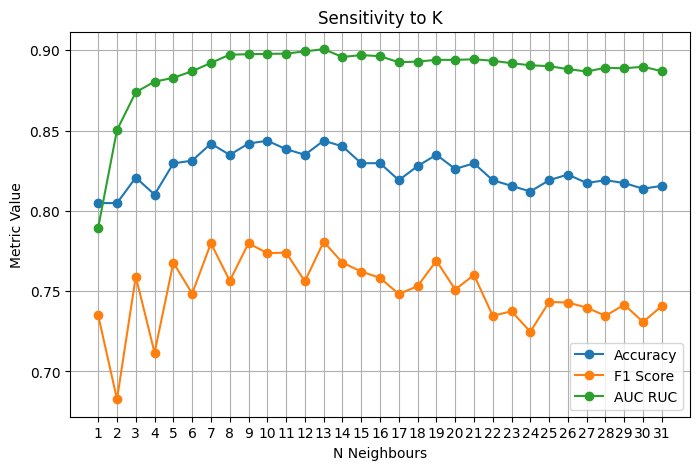

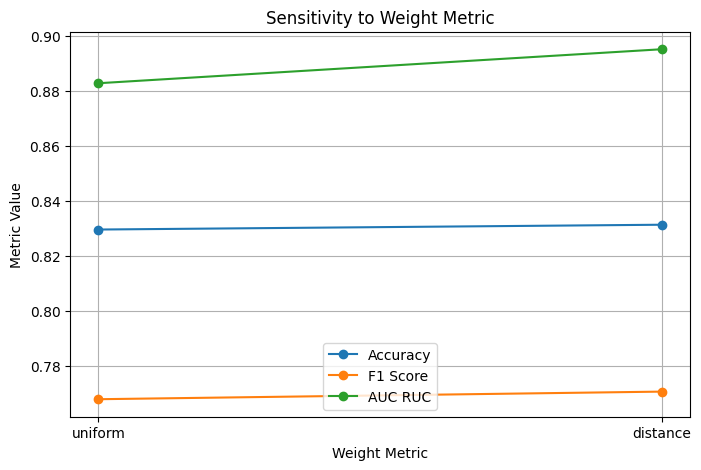

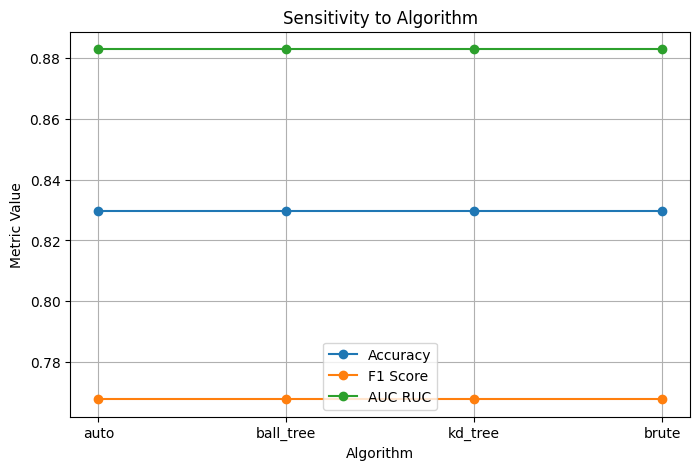

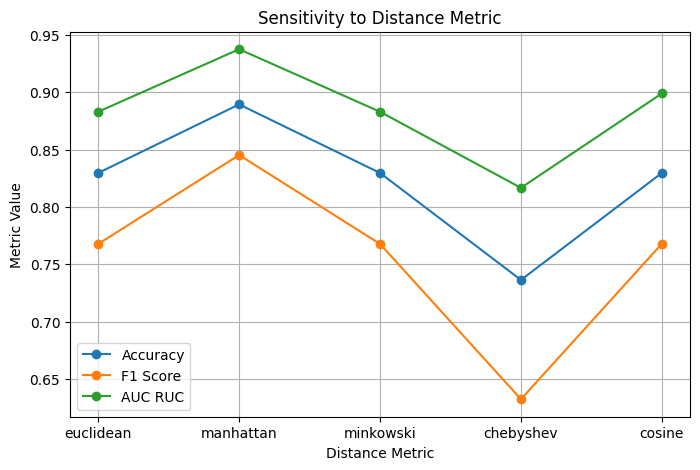

In [ ]:
plot_metrics(df_knn_n_neighbours, "N Neighbours", "Sensitivity to K")
plot_metrics(df_knn_weightmetric, "Weight Metric", "Sensitivity to Weight Metric")
plot_metrics(df_knn_algorithms, "Algorithm", "Sensitivity to Algorithm")
plot_metrics(df_knn_distmetric, "Distance Metric", "Sensitivity to Distance Metric")

# DECISION TREES

In [ ]:
print("3. DECISION TREES")

# Hyperparameter values
criteria = ['gini','entropy','log_loss']
max_depths = [None,2,3,5,10,15,20]
min_samples_splits = [2,5,10,15,20]
min_samples_leafs = [1,2,5,8,10]
max_features = [None, 'sqrt', 'log2']

print("\nPerforming Hyperparameter Evaluation for Decision Trees...")

###############################################################
# 1 — Across Criteria
###############################################################
dt_criteria_results = []
for c in criteria:

    model = DecisionTreeClassifier(criterion=c)
    metrics = evaluate_model(model, X, y, cv=10)
    dt_criteria_results.append({
        'Criterion': c,
        'Max Depth': None,
        'Min Samples Split': 2,
        'Min Samples Leaf': 1,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 2 — Across Max Depths
###############################################################
dt_maxdepth_results = []
for d in max_depths:
    model = DecisionTreeClassifier(max_depth=d)
    metrics = evaluate_model(model, X, y, cv=10)
    dt_maxdepth_results.append({
        'Criterion': 'entropy',
        'Max Depth': d,
        'Min Samples Split': 2,
        'Min Samples Leaf': 1,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 3 — Across Min Samples Splits
###############################################################
dt_minsamplesplit_results = []
for s in min_samples_splits:
    model = DecisionTreeClassifier(min_samples_split=s)
    metrics = evaluate_model(model, X, y, cv=5)
    dt_minsamplesplit_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': s,
        'Min Samples Leaf': 1,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 4 — Across Min Samples Leafs
###############################################################
dt_minsamplesleaf_results = []
for l in min_samples_leafs:
    model = DecisionTreeClassifier(min_samples_leaf=l)
    metrics = evaluate_model(model, X, y, cv=5)
    dt_minsamplesleaf_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': 2,
        'Min Samples Leaf': l,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# 5 — Across Max Features
###############################################################
dt_maxfeatures_results = []
for f in max_features:
    model = DecisionTreeClassifier(max_features=f)
    metrics = evaluate_model(model, X, y, cv=5)
    dt_maxfeatures_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': 2,
        'Min Samples Leaf': 1,
        'Max Features' : f,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

###############################################################
# Convert to DataFrames
###############################################################
df_dt_criteria = pd.DataFrame(dt_criteria_results)
df_dt_maxdepth = pd.DataFrame(dt_maxdepth_results)
df_dt_minsamplesplit = pd.DataFrame(dt_minsamplesplit_results)
df_dt_minsamplesleaf = pd.DataFrame(dt_minsamplesleaf_results)
df_dt_maxfeatures = pd.DataFrame(dt_maxfeatures_results)

###############################################################
# Calculate and Print Variances
###############################################################
# Calculate variances of the MEAN metrics for each hyperparameter
hp_dt_crit_acc = df_dt_criteria['Mean Accuracy'].var()
hp_dt_crit_f1 = df_dt_criteria['Mean F1'].var()
hp_dt_crit_auc = df_dt_criteria['Mean AUC'].var()

hp_dt_maxd_acc = df_dt_maxdepth['Mean Accuracy'].var()
hp_dt_maxd_f1 = df_dt_maxdepth['Mean F1'].var()
hp_dt_maxd_auc = df_dt_maxdepth['Mean AUC'].var()

hp_dt_split_acc = df_dt_minsamplesplit['Mean Accuracy'].var()
hp_dt_split_f1 = df_dt_minsamplesplit['Mean F1'].var()
hp_dt_split_auc = df_dt_minsamplesplit['Mean AUC'].var()

hp_dt_leaf_acc = df_dt_minsamplesleaf['Mean Accuracy'].var()
hp_dt_leaf_f1 = df_dt_minsamplesleaf['Mean F1'].var()
hp_dt_leaf_auc = df_dt_minsamplesleaf['Mean AUC'].var()

hp_dt_maxf_acc = df_dt_maxfeatures['Mean Accuracy'].var()
hp_dt_maxf_f1 = df_dt_maxfeatures['Mean F1'].var()
hp_dt_maxf_auc = df_dt_maxfeatures['Mean AUC'].var()


print("\nVariance Across Decision Tree Hyperparameters:")
print("Criteria Variance (Mean Accuracy):", hp_dt_crit_acc)
print("Criteria Variance (Mean F1):", hp_dt_crit_f1)
print("Criteria Variance (Mean AUC):", hp_dt_crit_auc)

print("Max Depth Variance (Mean Accuracy):", hp_dt_maxd_acc)
print("Max Depth Variance (Mean F1):", hp_dt_maxd_f1)
print("Max Depth Variance (Mean AUC):", hp_dt_maxd_auc)

print("Min Samples Split Variance (Mean Accuracy):", hp_dt_split_acc)
print("Min Samples Split Variance (Mean F1):", hp_dt_split_f1)
print("Min Samples Split Variance (Mean AUC):", hp_dt_split_auc)

print("Min Samples Leaf Variance (Mean Accuracy):", hp_dt_leaf_acc)
print("Min Samples Leaf Variance (Mean F1):", hp_dt_leaf_f1)
print("Min Samples Leaf Variance (Mean AUC):", hp_dt_leaf_auc)

print("Max Features Variance (Mean Accuracy):", hp_dt_maxf_acc)
print("Max Features Variance (Mean F1):", hp_dt_maxf_f1)
print("Max Features Variance (Mean AUC):", hp_dt_maxf_auc)

3. DECISION TREES

Performing Hyperparameter Evaluation for Decision Trees...

Variance Across Decision Tree Hyperparameters:
Criteria Variance (Mean Accuracy): 0.00010259567046270581
Criteria Variance (Mean F1): 0.0002040010988107794
Criteria Variance (Mean AUC): 0.00013597904854217987
Max Depth Variance (Mean Accuracy): 1.650910716043067e-05
Max Depth Variance (Mean F1): 3.377735818549524e-05
Max Depth Variance (Mean AUC): 6.620915709320727e-05
Min Samples Split Variance (Mean Accuracy): 4.9300517920524467e-05
Min Samples Split Variance (Mean F1): 7.700322675640029e-05
Min Samples Split Variance (Mean AUC): 0.00013802245213985438
Min Samples Leaf Variance (Mean Accuracy): 0.00018103760114047637
Min Samples Leaf Variance (Mean F1): 0.00027208728017215437
Min Samples Leaf Variance (Mean AUC): 0.0007787227964790291
Max Features Variance (Mean Accuracy): 9.415364328763844e-05
Max Features Variance (Mean F1): 0.00011698035885825613
Max Features Variance (Mean AUC): 5.022230422376949e-05


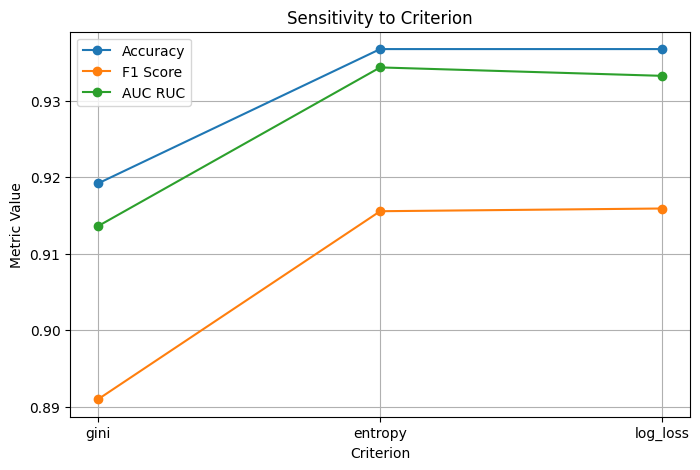

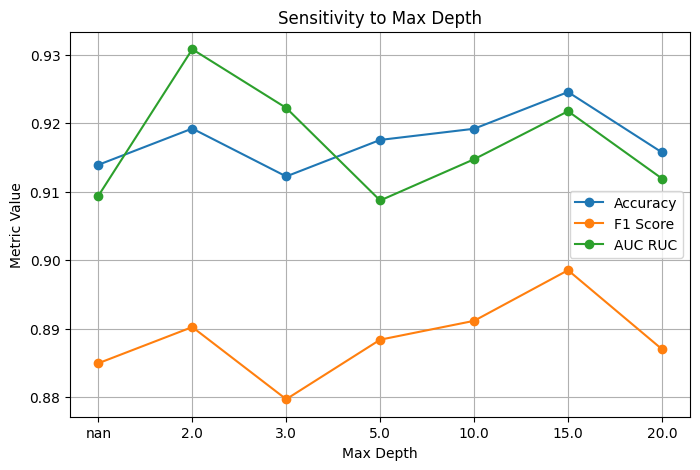

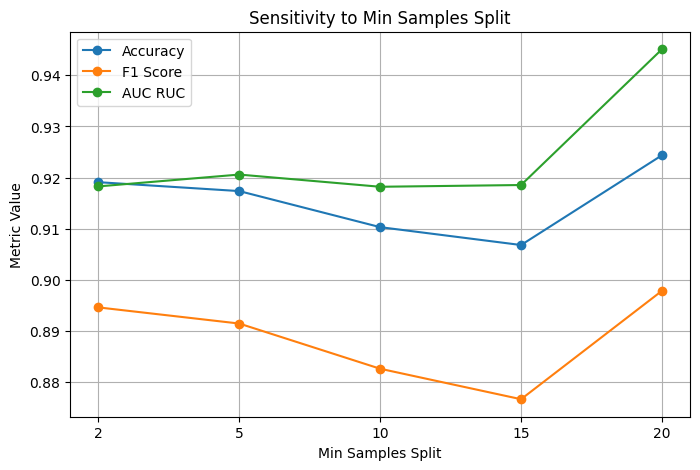

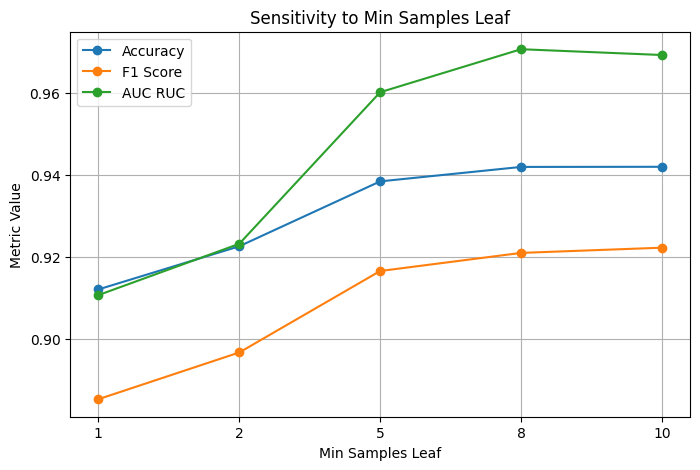

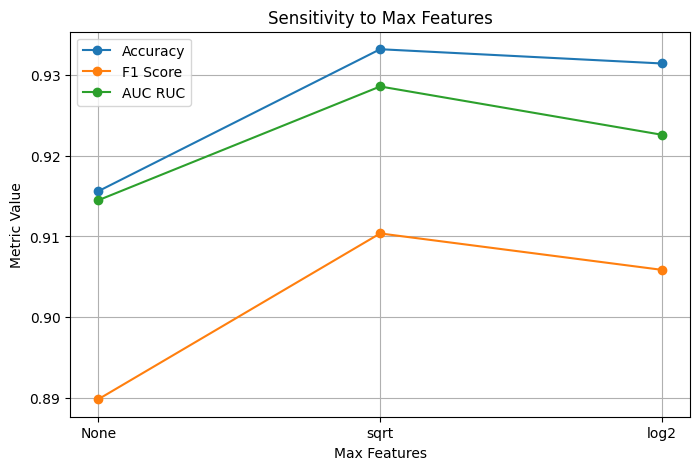

In [ ]:
plot_metrics(df_dt_criteria, "Criterion", "Sensitivity to Criterion")
plot_metrics(df_dt_maxdepth, "Max Depth", "Sensitivity to Max Depth")
plot_metrics(df_dt_minsamplesplit, "Min Samples Split", "Sensitivity to Min Samples Split")
plot_metrics(df_dt_minsamplesleaf, "Min Samples Leaf", "Sensitivity to Min Samples Leaf")
plot_metrics(df_dt_maxfeatures, "Max Features", "Sensitivity to Max Features")

# SVM

In [ ]:
# ---------------------------------------------------------
# HYPERPARAMETER GRIDS
# ---------------------------------------------------------
C_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
degrees = [2, 3, 4, 5]
gammas = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

# ---------------------------------------------------------
# STORAGE LISTS
# ---------------------------------------------------------
results_C = []
results_kernel = []
results_degree = []
results_gamma = []

# =========================================================
# 1. C VALUES
# =========================================================
for c in C_vals:
    model = SVC(C=c, kernel='rbf', gamma='scale', probability=True)

    metrics = evaluate_model(model, X, y, cv=5)

    results_C.append({
        'C': c,
        'Kernel': 'rbf',
        'Degree': None,
        'Gamma': 'scale',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

df_C = pd.DataFrame(results_C)

# =========================================================
# 2. KERNEL VALUES
# =========================================================
for k in kernels:
    model = SVC(kernel=k,
                degree=3 if k=='poly' else 3,
                gamma='scale',
                probability=True)

    metrics = evaluate_model(model, X, y, cv=5)

    results_kernel.append({
        'C': 1.0,
        'Kernel': k,
        'Degree': 3 if k=='poly' else None,
        'Gamma': 'scale',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

df_kernel = pd.DataFrame(results_kernel)

# =========================================================
# 3. DEGREE (POLY ONLY)
# =========================================================
for d in degrees:
    model = SVC(kernel='poly', degree=d, gamma='scale', probability=True)

    metrics = evaluate_model(model, X, y, cv=5)

    results_degree.append({
        'C': 1.0,
        'Kernel': 'poly',
        'Degree': d,
        'Gamma': 'scale',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

df_degree = pd.DataFrame(results_degree)

# =========================================================
# 4. GAMMA
# =========================================================
for g in gammas:
    model = SVC(kernel='rbf', gamma=g, probability=True)

    metrics = evaluate_model(model, X, y, cv=5)

    results_gamma.append({
        'C': 1.0,
        'Kernel': 'rbf',
        'Degree': None,
        'Gamma': g,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

df_gamma = pd.DataFrame(results_gamma)

# =========================================================
# VARIANCES OF EACH HYPERPARAMETER
# =========================================================

svm_hp_cval_acc = (df_C['Mean Accuracy'].var())
svm_hp_kern_acc = (df_kernel['Mean Accuracy'].var())
svm_hp_degr_acc = (df_degree['Mean Accuracy'].var())
svm_hp_gamm_acc = (df_gamma['Mean Accuracy'].var())

svm_hp_cval_f1 = (df_C['Mean F1'].var())
svm_hp_kern_f1 = (df_kernel['Mean F1'].var())
svm_hp_degr_f1 = (df_degree['Mean F1'].var())
svm_hp_gamm_f1 = (df_gamma['Mean F1'].var())

svm_hp_cval_auc = (df_C['Mean AUC'].var())
svm_hp_kern_auc = (df_kernel['Mean AUC'].var())
svm_hp_degr_auc = (df_degree['Mean AUC'].var())
svm_hp_gamm_auc = (df_gamma['Mean AUC'].var())

print("C (Accuracy) : " + str(svm_hp_cval_acc))
print("Kernel (Accuracy) : " + str(svm_hp_kern_acc))
print("Degree for Poly Kernel (Accuracy) : " + str(svm_hp_degr_acc))
print("Gamma (Accuracy) : " + str(svm_hp_gamm_acc))
print("\n")
print("C (F1 Score) : " + str(svm_hp_cval_f1))
print("Kernel (F1 Score) : " + str(svm_hp_kern_f1))
print("Degree for Poly Kernel (F1 Score) : " + str(svm_hp_degr_f1))
print("Gamma (F1 Score) : " + str(svm_hp_gamm_f1))
print("\n")
print("C (AUC) : " + str(svm_hp_cval_auc))
print("Kernel (AUC) : " + str(svm_hp_kern_auc))
print("Degree for Poly Kernel (AUC) : " + str(svm_hp_degr_auc))
print("Gamma (AUC) : " + str(svm_hp_gamm_auc))
print("\n")

C (Accuracy) : 0.01581528027797548
Kernel (Accuracy) : 0.015345281434370549
Degree for Poly Kernel (Accuracy) : 0.0005027951756139553
Gamma (Accuracy) : 0.011434674386257695


C (F1 Score) : 0.16299767377550547
Kernel (F1 Score) : 0.0736339530183751
Degree for Poly Kernel (F1 Score) : 0.0077652178669055695
Gamma (F1 Score) : 0.1186785137163346


C (AUC) : 0.0010884054716181126
Kernel (AUC) : 0.010514298070887733
Degree for Poly Kernel (AUC) : 0.016563442485683505
Gamma (AUC) : 0.04105227939025563




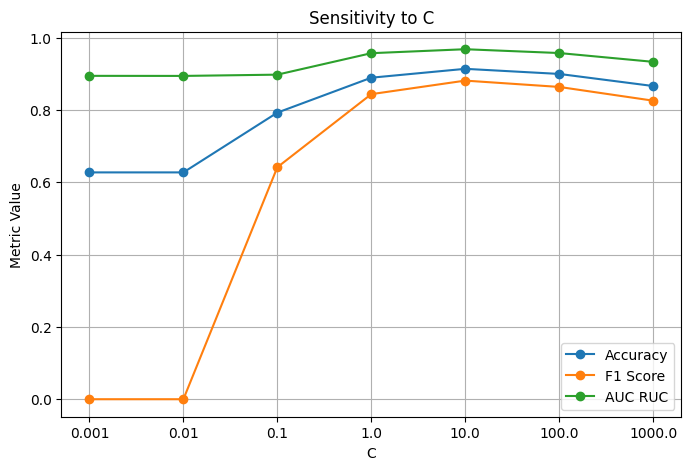

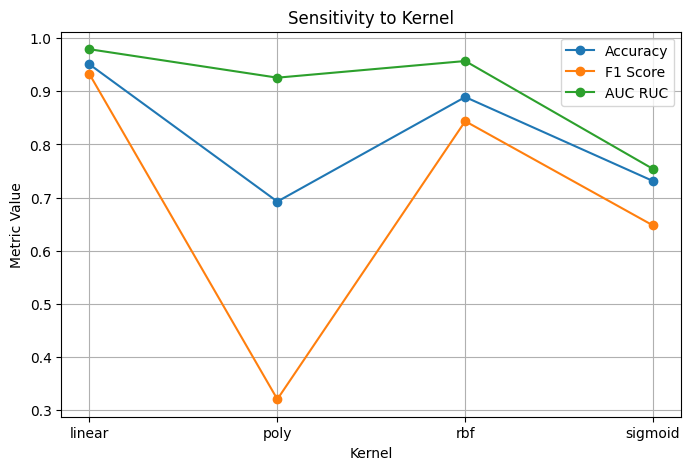

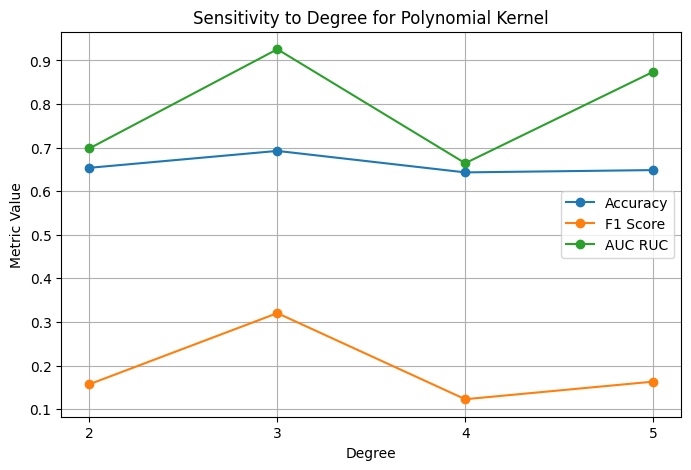

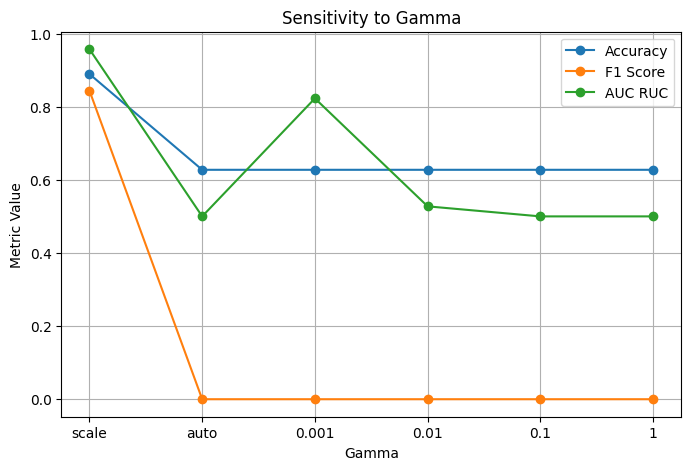

In [ ]:
plot_metrics(df_C, "C", "Sensitivity to C")
plot_metrics(df_kernel, "Kernel", "Sensitivity to Kernel")
plot_metrics(df_degree, "Degree", "Sensitivity to Degree for Polynomial Kernel")
plot_metrics(df_gamma, "Gamma", "Sensitivity to Gamma")

# MLP

In [ ]:
print("2. MULTI-LAYER PERCEPTRON (MLP)")
#print("\nPerforming Hyperparameter Evaluation...")

hidden_layers = [(10,),(50,),(100,),(10, 10),(50, 50),(100, 50)]
activations = ['identity', 'logistic', 'tanh', 'relu']
alphas = [0.0001, 0.001, 0.01, 0.1,1, 10, 100, 1000]
learning_rates = ['constant', 'invscaling', 'adaptive'] # only if solver is sgd
learning_rate_inits = [0.0001, 0.001, 0.01, 0.1]

#defining storage dictionaries
results_hidden = []
results_activation = []
results_alpha = []
results_lr = []
results_lr_init = []

#hidden layer sizes
for h in hidden_layers:
    model = MLPClassifier(
        hidden_layer_sizes=h,
        solver='lbfgs',
        max_iter=3000,
        random_state = 42,
        early_stopping=True
    )

    metrics = evaluate_model(model, X, y, cv=10)

    results_hidden.append({
        'Hyperparameter': 'Hidden Layer Sizes',
        'Value': h,
        'Mean Accuracy': metrics['Mean Accuracy'],
        'Mean AUC': metrics['Mean AUC'],
        'Mean F1': metrics['Mean F1 Score']
    })

for act in activations:
    model = MLPClassifier(
        activation=act,
        max_iter=3000,
        random_state = 42,
        early_stopping=True
    )

    metrics = evaluate_model(model, X, y, cv=10)

    results_activation.append({
        'Hyperparameter': 'Activation',
        'Value': act,
        'Mean Accuracy': metrics['Mean Accuracy'],
        'Mean AUC': metrics['Mean AUC'],
        'Mean F1': metrics['Mean F1 Score']
    })


for a in alphas:
    model = MLPClassifier(
        alpha=a,
        max_iter=3000,
        random_state = 42,
        early_stopping=True
    )

    metrics = evaluate_model(model, X, y, cv=10)

    results_alpha.append({
        'Hyperparameter': 'Alpha',
        'Value': a,
        'Mean Accuracy': metrics['Mean Accuracy'],
        'Mean AUC': metrics['Mean AUC'],
        'Mean F1': metrics['Mean F1 Score']
    })

for lr in learning_rates:
    model = MLPClassifier(
        learning_rate=lr,
        solver='sgd',
        max_iter=3000,
        random_state = 42,
        early_stopping=True
    )

    metrics = evaluate_model(model, X, y, cv=10)

    results_lr.append({
        'Hyperparameter': 'Learning Rate',
        'Value': lr,
        'Mean Accuracy': metrics['Mean Accuracy'],
        'Mean AUC': metrics['Mean AUC'],
        'Mean F1': metrics['Mean F1 Score']
    })
for lr0 in learning_rate_inits:
    model = MLPClassifier(
        learning_rate_init=lr0,
        max_iter=3000,
        random_state = 42,
        early_stopping=True
    )

    metrics = evaluate_model(model, X, y, cv=10)

    results_lr_init.append({
        'Hyperparameter': 'Learning Rate Init',
        'Value': lr0,
        'Mean Accuracy': metrics['Mean Accuracy'],
        'Mean AUC': metrics['Mean AUC'],
        'Mean F1': metrics['Mean F1 Score']
    })

#converting to dataframes
df_hidden = pd.DataFrame(results_hidden)
df_activation = pd.DataFrame(results_activation)
df_alpha = pd.DataFrame(results_alpha)
df_lr = pd.DataFrame(results_lr)
df_lr_init = pd.DataFrame(results_lr_init)

#computation for accross parameters

mlp_hp_hidd_acc = (df_hidden['Mean Accuracy'].var())
mlp_hp_acti_acc = (df_activation['Mean Accuracy'].var())
mlp_hp_alph_acc = (df_alpha['Mean Accuracy'].var())
mlp_hp_lear_acc = (df_lr['Mean Accuracy'].var())
mlp_hp_inlr_acc = (df_lr_init['Mean Accuracy'].var())

mlp_hp_hidd_f1 = (df_hidden['Mean F1'].var())
mlp_hp_acti_f1 = (df_activation['Mean F1'].var())
mlp_hp_alph_f1 = (df_alpha['Mean F1'].var())
mlp_hp_lear_f1 = (df_lr['Mean F1'].var())
mlp_hp_inlr_f1 = (df_lr_init['Mean F1'].var())

mlp_hp_hidd_auc = (df_hidden['Mean AUC'].var())
mlp_hp_acti_auc = (df_activation['Mean AUC'].var())
mlp_hp_alph_auc = (df_alpha['Mean AUC'].var())
mlp_hp_lear_auc = (df_lr['Mean AUC'].var())
mlp_hp_inlr_auc = (df_lr_init['Mean AUC'].var())

print("Hidden Layer Sizes (Accuracy) : " + str(mlp_hp_hidd_acc))
print("Activation Function (Accuracy) : " + str(mlp_hp_acti_acc))
print("Alpha (Accuracy) : " + str(mlp_hp_alph_acc))
print("Learning Rate (Accuracy) : " + str(mlp_hp_lear_acc))
print("Learning Rate Init (Accuracy) : " + str(mlp_hp_inlr_acc))
print("\n")
print("Hidden Layer Sizes (F1 Score) : " + str(mlp_hp_hidd_f1))
print("Activation Function (F1 Score) : " + str(mlp_hp_acti_f1))
print("Alpha (F1 Score) : " + str(mlp_hp_alph_f1))
print("Learning Rate (F1 Score) : " + str(mlp_hp_lear_f1))
print("Learning Rate Init (F1 Score) : " + str(mlp_hp_inlr_f1))
print("\n")
print("Hidden Layer Sizes (AUC) : " + str(mlp_hp_hidd_auc))
print("Activation Function (AUC) : " + str(mlp_hp_acti_auc))
print("Alpha (AUC) : " + str(mlp_hp_alph_auc))
print("Learning Rate (AUC) : " + str(mlp_hp_lear_auc))
print("Learning Rate Init (AUC) : " + str(mlp_hp_inlr_auc))

2. MULTI-LAYER PERCEPTRON (MLP)
Hidden Layer Sizes (Accuracy) : 4.0315289319790574e-05
Activation Function (Accuracy) : 0.0013114743050190185
Alpha (Accuracy) : 0.0008019685406397746
Learning Rate (Accuracy) : 0.0065925311529659355
Learning Rate Init (Accuracy) : 0.00973668727936696


Hidden Layer Sizes (F1 Score) : 7.082739090262755e-05
Activation Function (F1 Score) : 0.0027606180736766055
Alpha (F1 Score) : 0.0018494973511537034
Learning Rate (F1 Score) : 0.011831177806014118
Learning Rate Init (F1 Score) : 0.016587191483608585


Hidden Layer Sizes (AUC) : 2.207653727824933e-05
Activation Function (AUC) : 0.000568216572804979
Alpha (AUC) : 0.0008234815085304505
Learning Rate (AUC) : 0.005569836828183192
Learning Rate Init (AUC) : 0.011943550733998798


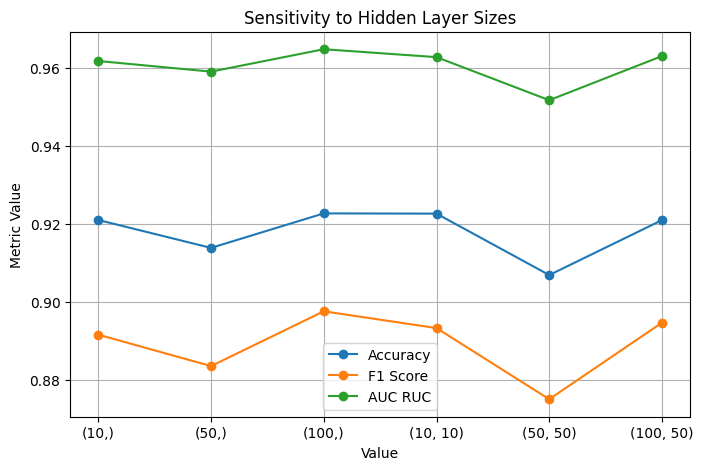

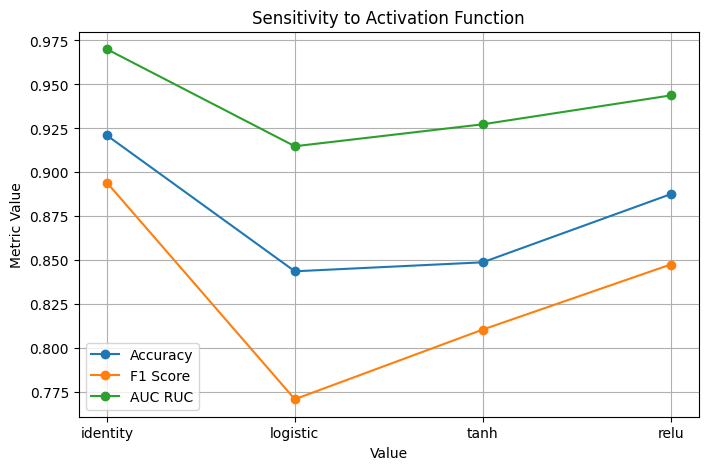

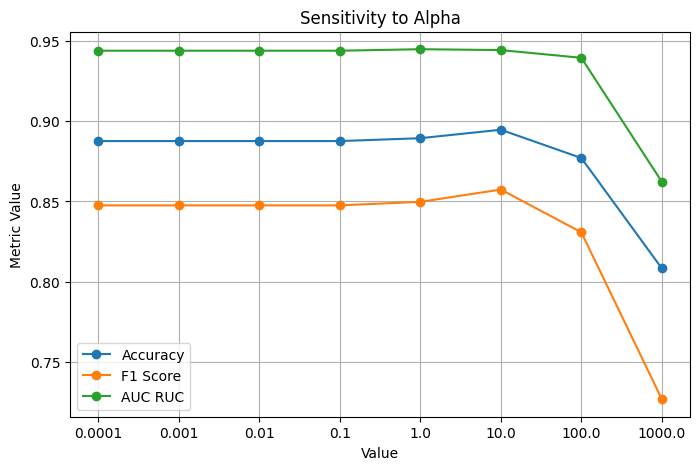

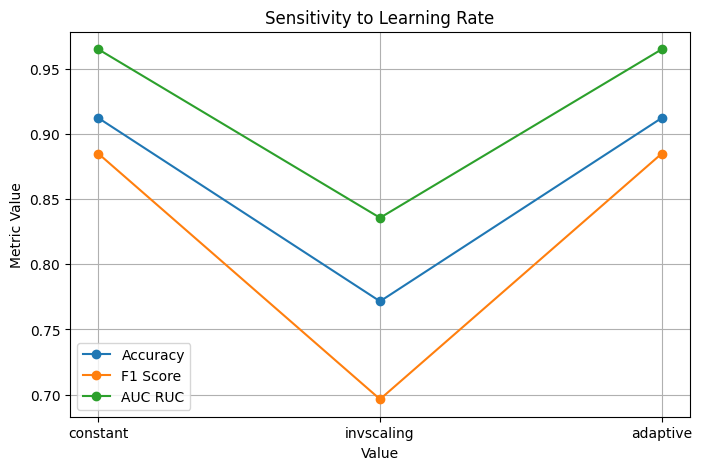

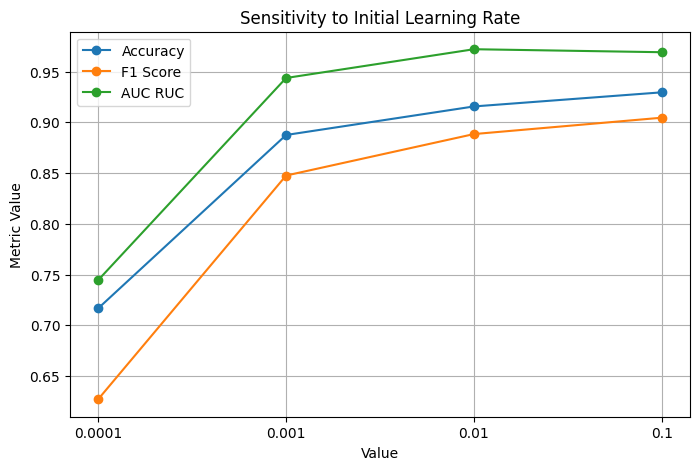

In [ ]:
plot_metrics(df_hidden, "Value", "Sensitivity to Hidden Layer Sizes")
plot_metrics(df_activation, "Value", "Sensitivity to Activation Function")
plot_metrics(df_alpha, "Value", "Sensitivity to Alpha")
plot_metrics(df_lr, "Value", "Sensitivity to Learning Rate")
plot_metrics(df_lr_init, "Value", "Sensitivity to Initial Learning Rate")